In [4]:
import numpy as np
import scipy.io as sio
import vtk
from scipy.interpolate import interp1d
from vtk.util.numpy_support import numpy_to_vtk

import os
import cv2
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..", "Code")))
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import pandas as pd
from scripts.visualization.utils.renderizer import EGMRenderer_EGM


In [5]:
algorithm_ID="OMAMI_VAE_Optuna_1"
algorithm_ID_tik="OMAMI_VAE_Optuna_1"

In [6]:


csv_dl=f"/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/{algorithm_ID}/metrics_dl.csv"
df_dl = pd.read_csv(csv_dl)
df_dl = df_dl.sort_values(by='mean correlation', ascending=False)

df_dl.rename(columns={'name': 'name', 'mean correlation': 'MeanCorr DL', 'mean RMSE': 'MeanRMSE DL'}, inplace=True)
df_DL=np.round(df_dl, 3)
df_dl.head(20)



,name,MeanCorr DL,MeanRMSE DL
2,Simulation_01_200212_001_ 5,0.613363,0.463294
4,Simulation_01_200316_001_ 3,0.604924,0.467020
5,Simulation_01_200316_001_ 4,0.122069,0.567196
9,Simulation_01_200428_001_010,0.115779,0.569530
7,Simulation_01_200428_001_004,0.067855,0.580002
8,Simulation_01_200428_001_008,0.044534,0.602780
10,Simulation_01_210119_001_001,0.028090,0.561961
3,Simulation_01_200212_001_ 10,0.021143,0.605160
1,LA_RSPV_CAF_150115,0.007695,0.635791
6,Simulation_01_200316_001_ 8,0.004256,0.596477


In [7]:
print('DL --> Mean corr: ', np.round(df_DL['MeanCorr DL'].mean(), 3), '+-', np.round(df_DL['MeanCorr DL'].std(), 3) )
print('DL --> Mean RMSE: ', np.round(df_DL['MeanRMSE DL'].mean(), 3), '+-', np.round(df_DL['MeanRMSE DL'].std(), 3) )

DL --> Mean corr:  0.135 +- 0.225
DL --> Mean RMSE:  0.57 +- 0.053


In [8]:
sinusal = {
    "Simulation_01_200316_001_  7", "Simulation_01_210209_001_002",
    "Simulation_01_210205_001_002", "Simulation_01_200428_001_001",
    "Simulation_01_200316_001_ 5", "Simulation_01_200428_001_005",
    "Simulation_01_200212_001_  7", "Simulation_01_210119_001_001",
    "Simulation_01_210205_001_003", "Simulation_01_201223_001_002",
    "Simulation_01_200212_001_  1", "Simulation_01_200428_001_003",
    "Simulation_01_200316_001_  3", "Simulation_01_200316_001_  4",
    "Sinusal_150629", "RA_RAA_141216", "Simulation_01_200428_001_002",
    "Simulation_01_210210_001_001", "Simulation_01_210208_001_002",
    "Simulation_01_200212_001_  9", "Simulation_01_200316_001_  1",
    "Simulation_01_200212_001_  6", "Simulation_01_200212_001_  5",
    "Simulation_01_210209_001_003", "Simulation_01_200316_001_  9",
    "Simulation_01_210209_001_001", "Simulation_01_200428_001_006",
    "Simulation_01_200316_001_  5",
}

rotor_simple = {
    "Simulation_01_200212_001_  2", "Simulation_01_191001_001_002",
    "Simulation_01_190717_001_001", "Simulation_01_191001_001_007",
    "Simulation_01_190717_001_004", "Simulation_01_190619_001_003",
    "Simulation_01_190619_001_004", "Simulation_01_190717_001_003",
    "Simulation_01_190502_001_006", "Simulation_01_190502_001_004",
    "Simulation_01_190717_001_002", "Simulation_01_190619_001_001",
    "Simulation_01_200316_001_  8", "Simulation_01_200428_001_004",
    "Simulation_01_200212_001_  8", "Simulation_01_200212_001_10",
    "Simulation_01_191001_001_001", "Simulation_01_200428_001_007",
    "Simulation_01_200428_001_009", "Simulation_01_200428_001_010",
    "Simulation_01_200316_001_  2", "Simulation_01_200316_001_  6",
    "Simulation_01_200316_001_10", "Simulation_01_190502_001_003",
    "Simulation_01_190619_001_002", "Simulation_01_191001_001_005",
    "Simulation_01_200212_001_  4", "Simulation_01_200212_001_ 10",
    "Simulation_01_200428_001_008", "Simulation_01_190502_001_005"

}

rotor_complejo = {
    "LA_RSPV_CAF_150115", "LA_RSPV_150113'", "LA_PLAW_140612",
    "LA_LSPV_150203", "LA_LSPV_150113", "RA_RAFW_140807",
    "RA_RAA_141230", "TwoRotors_181219", "LA_PLAW_140711_arm",
    "RA_RAFW_SAF_140730", "LA_RIPV_150121", "LA_LIPV_150119"
}

# Función para clasificar cada fila
def classify_row(name):
    if name in sinusal:
        return 'Frente de Onda Sinusal'
    elif name in rotor_simple:
        return 'Rotor Simple'
    elif name in rotor_complejo:
        return 'Rotor Complejo'
    else:
        return 'Desconocido'




In [9]:
# Crear la nueva columna de clasificación
df_DL['classification'] = df_DL['name'].apply(classify_row)

print(df_DL)

                            name  MeanCorr DL  MeanRMSE DL  \
2   Simulation_01_200212_001_  5        0.613        0.463   
4   Simulation_01_200316_001_  3        0.605        0.467   
5   Simulation_01_200316_001_  4        0.122        0.567   
9   Simulation_01_200428_001_010        0.116        0.570   
7   Simulation_01_200428_001_004        0.068        0.580   
8   Simulation_01_200428_001_008        0.045        0.603   
10  Simulation_01_210119_001_001        0.028        0.562   
3   Simulation_01_200212_001_ 10        0.021        0.605   
1             LA_RSPV_CAF_150115        0.008        0.636   
6   Simulation_01_200316_001_  8        0.004        0.596   
0             LA_PLAW_140711_arm        0.002        0.583   
11  Simulation_01_210208_001_002       -0.007        0.606   

            classification  
2   Frente de Onda Sinusal  
4   Frente de Onda Sinusal  
5   Frente de Onda Sinusal  
9             Rotor Simple  
7             Rotor Simple  
8             Rotor

In [10]:


csv_tik=f"/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/{algorithm_ID_tik}/metrics_tik.csv"
df_tik = pd.read_csv(csv_tik)
df_tik = df_tik.sort_values(by='mean correlation', ascending=False)

df_tik.rename(columns={'name': 'name', 'mean correlation': 'MeanCorr ZOT', 'mean RMSE': 'MeanRMSE ZOT'}, inplace=True)
df_tik=np.round(df_tik, 3)
 #Crear la nueva columna de clasificación
df_tik['classification'] = df_DL['name'].apply(classify_row)
df_tik.head(20)

,name,MeanCorr ZOT,MeanRMSE ZOT,classification
11,Simulation_01_210208_001_002,0.264,0.579,Frente de Onda Sinusal
10,Simulation_01_210119_001_001,0.225,0.565,Frente de Onda Sinusal
7,Simulation_01_200428_001_004,0.088,0.538,Rotor Simple
9,Simulation_01_200428_001_010,0.083,0.529,Rotor Simple
8,Simulation_01_200428_001_008,0.082,0.538,Rotor Simple
6,Simulation_01_200316_001_ 8,0.081,0.562,Rotor Simple
0,LA_PLAW_140711_arm,0.077,0.547,Rotor Complejo
5,Simulation_01_200316_001_ 4,0.074,0.552,Frente de Onda Sinusal
1,LA_RSPV_CAF_150115,0.060,0.583,Rotor Complejo
3,Simulation_01_200212_001_ 10,0.043,0.575,Rotor Simple


In [11]:
print('ZOT --> Mean corr: ', np.round(df_tik['MeanCorr ZOT'].mean(), 3), '+-', np.round(df_tik['MeanCorr ZOT'].std(), 3) )
print('ZOT --> Mean RMSE: ', np.round(df_tik['MeanRMSE ZOT'].mean(), 3), '+-', np.round(df_tik['MeanRMSE ZOT'].std(), 3) )
print('DL --> Mean corr: ', np.round(df_DL['MeanCorr DL'].mean(), 3), '+-', np.round(df_DL['MeanCorr DL'].std(), 3) )
print('DL --> Mean RMSE: ', np.round(df_DL['MeanRMSE DL'].mean(), 3), '+-', np.round(df_DL['MeanRMSE DL'].std(), 3) )


ZOT --> Mean corr:  0.095 +- 0.073
ZOT --> Mean RMSE:  0.555 +- 0.018
DL --> Mean corr:  0.135 +- 0.225
DL --> Mean RMSE:  0.57 +- 0.053


In [12]:
df_merged = pd.merge(df_DL,df_tik, on='name')
df_merged.head(20)


,name,MeanCorr DL,MeanRMSE DL,classification_x,MeanCorr ZOT,MeanRMSE ZOT,classification_y
0,Simulation_01_200212_001_ 5,0.613,0.463,Frente de Onda Sinusal,0.030,0.554,Frente de Onda Sinusal
1,Simulation_01_200316_001_ 3,0.605,0.467,Frente de Onda Sinusal,0.031,0.534,Frente de Onda Sinusal
2,Simulation_01_200316_001_ 4,0.122,0.567,Frente de Onda Sinusal,0.074,0.552,Frente de Onda Sinusal
3,Simulation_01_200428_001_010,0.116,0.570,Rotor Simple,0.083,0.529,Rotor Simple
4,Simulation_01_200428_001_004,0.068,0.580,Rotor Simple,0.088,0.538,Rotor Simple
5,Simulation_01_200428_001_008,0.045,0.603,Rotor Simple,0.082,0.538,Rotor Simple
6,Simulation_01_210119_001_001,0.028,0.562,Frente de Onda Sinusal,0.225,0.565,Frente de Onda Sinusal
7,Simulation_01_200212_001_ 10,0.021,0.605,Rotor Simple,0.043,0.575,Rotor Simple
8,LA_RSPV_CAF_150115,0.008,0.636,Rotor Complejo,0.060,0.583,Rotor Complejo
9,Simulation_01_200316_001_ 8,0.004,0.596,Rotor Simple,0.081,0.562,Rotor Simple


In [13]:
df_merged_sorted_by_zot = df_merged.sort_values(by='MeanCorr ZOT', ascending=False)
df_merged_sorted_by_zot.head(20)

,name,MeanCorr DL,MeanRMSE DL,classification_x,MeanCorr ZOT,MeanRMSE ZOT,classification_y
11,Simulation_01_210208_001_002,-0.007,0.606,Frente de Onda Sinusal,0.264,0.579,Frente de Onda Sinusal
6,Simulation_01_210119_001_001,0.028,0.562,Frente de Onda Sinusal,0.225,0.565,Frente de Onda Sinusal
4,Simulation_01_200428_001_004,0.068,0.580,Rotor Simple,0.088,0.538,Rotor Simple
3,Simulation_01_200428_001_010,0.116,0.570,Rotor Simple,0.083,0.529,Rotor Simple
5,Simulation_01_200428_001_008,0.045,0.603,Rotor Simple,0.082,0.538,Rotor Simple
9,Simulation_01_200316_001_ 8,0.004,0.596,Rotor Simple,0.081,0.562,Rotor Simple
10,LA_PLAW_140711_arm,0.002,0.583,Rotor Complejo,0.077,0.547,Rotor Complejo
2,Simulation_01_200316_001_ 4,0.122,0.567,Frente de Onda Sinusal,0.074,0.552,Frente de Onda Sinusal
8,LA_RSPV_CAF_150115,0.008,0.636,Rotor Complejo,0.060,0.583,Rotor Complejo
7,Simulation_01_200212_001_ 10,0.021,0.605,Rotor Simple,0.043,0.575,Rotor Simple


/tmp/ipykernel_339160/1151243277.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([numerical_columns[col] for col in rmse_columns], labels=rmse_columns)
/tmp/ipykernel_339160/1151243277.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([numerical_columns[col] for col in corr_columns], labels=corr_columns)


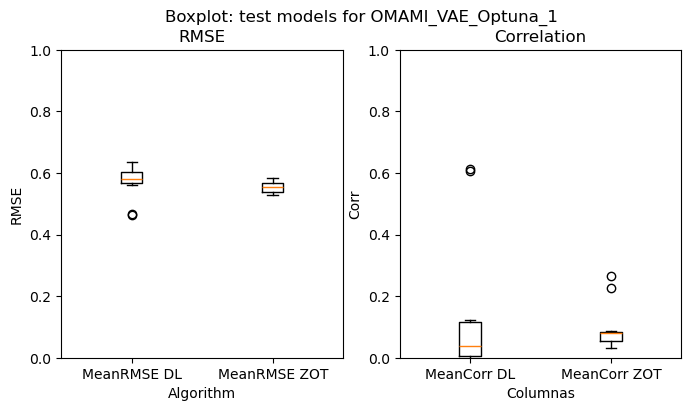

In [14]:
# Crear el boxplot solo con las columnas numéricas
numerical_columns = df_merged.select_dtypes(include="number")  # Seleccionar solo columnas numéricas
# Filtrar las columnas que contienen "RMSE" en su nombre
rmse_columns = [col for col in numerical_columns.columns if "RMSE" in col]
corr_columns = [col for col in numerical_columns.columns if "Corr" in col]


plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.boxplot([numerical_columns[col] for col in rmse_columns], labels=rmse_columns)
plt.title("RMSE")
plt.ylabel("RMSE")
plt.xlabel("Algorithm")
plt.ylim([0,1])
plt.subplot(1,2,2)
plt.boxplot([numerical_columns[col] for col in corr_columns], labels=corr_columns)
plt.title("Correlation")
plt.ylabel("Corr")
plt.xlabel("Columnas")
plt.ylim([0,1])
plt.suptitle(f"Boxplot: test models for {algorithm_ID}")
plt.show()


In [15]:
print('DL agregado --> Mean corr: ', np.round(df_DL['MeanCorr DL'].mean(), 3), '+-', np.round(df_DL['MeanCorr DL'].std(), 3) )
print('DL agregado --> Mean RMSE: ', np.round(df_DL['MeanRMSE DL'].mean(), 3), '+-', np.round(df_DL['MeanRMSE DL'].std(), 3) )

print('ZOT agregado--> Mean corr: ', np.round(df_tik['MeanCorr ZOT'].mean(), 3), '+-', np.round(df_tik['MeanCorr ZOT'].std(), 3) )
print('ZOT agregado --> Mean RMSE: ', np.round(df_tik['MeanRMSE ZOT'].mean(), 3), '+-', np.round(df_tik['MeanRMSE ZOT'].std(), 3) )


DL agregado --> Mean corr:  0.135 +- 0.225
DL agregado --> Mean RMSE:  0.57 +- 0.053
ZOT agregado--> Mean corr:  0.095 +- 0.073
ZOT agregado --> Mean RMSE:  0.555 +- 0.018


In [16]:
print(algorithm_ID)

OMAMI_VAE_Optuna_1
